# 🔬 VGG Model Training for C-NMC Leukemia Detection
## Complete Pipeline: VGG16 & VGG19 with 20 Epochs

**Dataset:** C-NMC 2019 Leukemia Classification

**Features:**
- ImageNet pre-trained weights
- Data normalization & augmentation
- 20 epochs training
- Accuracy & loss graphs
- Model comparison
- Best accuracy identification

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import cv2
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16, VGG19
import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("🔬 VGG TRAINING FOR C-NMC LEUKEMIA DETECTION")
print("="*70)
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print("="*70)

2026-04-05 14:14:56.071864: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775398496.278301      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775398496.343032      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775398496.834199      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775398496.834232      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775398496.834235      24 computation_placer.cc:177] computation placer alr

🔬 VGG TRAINING FOR C-NMC LEUKEMIA DETECTION
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 📂 Step 2: Auto-Detect Dataset Structure

In [2]:
print("\n" + "="*70)
print("📂 DETECTING DATASET STRUCTURE")
print("="*70)

BASE_PATH = '/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)'

# Find the actual dataset folder
def find_dataset_root(base):
    for root, dirs, files in os.walk(base):
        if 'all' in dirs and 'normal' in dirs:
            return root
        if any('all' in d.lower() for d in dirs) and any('normal' in d.lower() for d in dirs):
            return root
    return base

DATASET_ROOT = find_dataset_root(BASE_PATH)
print(f"Dataset root found: {DATASET_ROOT}")

# List contents
for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(DATASET_ROOT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for d in dirs[:5]:
        print(f"{subindent}{d}/")
    if len(dirs) > 5:
        print(f"{subindent}... ({len(dirs)-5} more)")

# Find all and normal directories
ALL_DIR = None
NORMAL_DIR = None

for root, dirs, files in os.walk(DATASET_ROOT):
    for d in dirs:
        if d.lower() == 'all':
            ALL_DIR = os.path.join(root, d)
        if d.lower() == 'normal':
            NORMAL_DIR = os.path.join(root, d)

if not ALL_DIR or not NORMAL_DIR:
    for root, dirs, files in os.walk(DATASET_ROOT):
        if 'all' in [d.lower() for d in dirs]:
            ALL_DIR = os.path.join(root, [d for d in dirs if d.lower() == 'all'][0])
        if 'normal' in [d.lower() for d in dirs]:
            NORMAL_DIR = os.path.join(root, [d for d in dirs if d.lower() == 'normal'][0])

print(f"\n✅ ALL_DIR: {ALL_DIR}")
print(f"✅ NORMAL_DIR: {NORMAL_DIR}")

if not ALL_DIR or not NORMAL_DIR:
    raise ValueError("Could not find 'all' and 'normal' directories!")

print("="*70)


📂 DETECTING DATASET STRUCTURE
Dataset root found: /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)
C-NMC(2019)/
  all/
  normal/
  all/
  normal/

✅ ALL_DIR: /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)/all
✅ NORMAL_DIR: /kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)/normal


## 🔍 Step 3: Load and Explore Images

In [3]:
print("="*70)
print("🔍 LOADING IMAGES WITH DEBUGGING")
print("="*70)

# Get all image filenames from both directories
all_images = [f for f in os.listdir(ALL_DIR) if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
normal_images = [f for f in os.listdir(NORMAL_DIR) if f.lower().endswith(('.bmp', '.jpg', '.jpeg', '.png', '.tif', '.tiff'))]

print(f"Total images in 'all': {len(all_images)}")
print(f"Total images in 'normal': {len(normal_images)}")

# DEBUG: Show first 5 filenames from each folder
print("\n🔍 First 5 files in 'all':")
for i in range(min(5, len(all_images))):
    print(f"  {all_images[i]}")

print("\n🔍 First 5 files in 'normal':")
for i in range(min(5, len(normal_images))):
    print(f"  {normal_images[i]}")

# Check for overlap
overlap = set(all_images) & set(normal_images)
print(f"\n🔍 Files in both folders: {len(overlap)}")

if len(overlap) == 0:
    print("\n⚠️ WARNING: No filename overlap detected!")
    print("This means files in 'normal' and 'all' have different names.")
    print("\nPossible reasons:")
    print("1. Files in 'normal' folder are NOT copies of files in 'all'")
    print("2. Files have different extensions or naming conventions")
    
    # Check if normal folder has DIFFERENT files
    print("\n🔍 Checking if 'normal' has separate files...")
    
    # Solution: Use BOTH folders separately
    print("\n✅ Using alternative labeling method...")
    print("   - Files in 'all' folder will be checked against 'normal' folder")
    print("   - If file exists in BOTH locations, it's NORMAL")
    print("   - Otherwise, it's LEUKEMIC")

print("="*70)

🔍 LOADING IMAGES WITH DEBUGGING
Total images in 'all': 7272
Total images in 'normal': 3389

🔍 First 5 files in 'all':
  UID_46_17_8_all.bmp
  UID_47_7_3_all.bmp
  UID_47_28_10_all.bmp
  UID_28_5_3_all.bmp
  UID_45_24_5_all.bmp

🔍 First 5 files in 'normal':
  UID_H23_5_5_hem.bmp
  UID_H14_7_7_hem.bmp
  UID_H12_18_4_hem.bmp
  UID_H14_27_7_hem.bmp
  UID_H17_3_2_hem.bmp

🔍 Files in both folders: 0

⚠️ WARNING: No filename overlap detected!
This means files in 'normal' and 'all' have different names.

Possible reasons:
1. Files in 'normal' folder are NOT copies of files in 'all'
2. Files have different extensions or naming conventions

🔍 Checking if 'normal' has separate files...

✅ Using alternative labeling method...
   - Files in 'all' folder will be checked against 'normal' folder
   - If file exists in BOTH locations, it's NORMAL
   - Otherwise, it's LEUKEMIC


## 📋 Step 4: Create Dataset with Labels

In [4]:
print("\n" + "="*70)
print("📋 CREATING DATASET (FIXED)")
print("="*70)

data = []
normal_count = 0
leukemic_count = 0

# Create set of normal filenames
normal_set = set(normal_images)

# Method 1: Check by filename
for img_name in all_images:
    img_path = os.path.join(ALL_DIR, img_name)
    
    if not os.path.exists(img_path):
        continue
    
    # Check if same filename exists in normal folder
    if img_name in normal_set:
        label = 0  # Normal
        normal_count += 1
    else:
        label = 1  # Leukemic
        leukemic_count += 1
    
    data.append({
        'filename': img_name,
        'filepath': img_path,
        'label': label
    })

# If Method 1 failed (no overlap), try Method 2: Separate folders
if normal_count == 0:
    print("\n⚠️ Filename matching failed. Using separate folder method...")
    data = []
    normal_count = 0
    leukemic_count = 0
    
    # Load from 'all' folder as leukemic
    for img_name in all_images:
        img_path = os.path.join(ALL_DIR, img_name)
        if os.path.exists(img_path):
            data.append({
                'filename': img_name,
                'filepath': img_path,
                'label': 1  # Assume all in 'all' are leukemic first
            })
            leukemic_count += 1
    
    # Load from 'normal' folder as normal
    for img_name in normal_images:
        img_path = os.path.join(NORMAL_DIR, img_name)
        if os.path.exists(img_path):
            data.append({
                'filename': img_name,
                'filepath': img_path,
                'label': 0  # Normal
            })
            normal_count += 1
            leukemic_count -= 1  # Adjust count
    
    print("✅ Using separate folder method")

df = pd.DataFrame(data)

print(f"\nTotal samples: {len(df)}")
print(f"Normal (0): {normal_count}")
print(f"Leukemic (1): {leukemic_count}")

# Verification
if normal_count == 0 or leukemic_count == 0:
    print("\n❌ ERROR: Still missing one class!")
    print("\nDEBUG INFO:")
    print(f"all_images count: {len(all_images)}")
    print(f"normal_images count: {len(normal_images)}")
    print(f"First 3 from all: {all_images[:3]}")
    print(f"First 3 from normal: {normal_images[:3]}")
    raise ValueError("Cannot create dataset with both classes!")

# Expected values
expected_normal = 3389
expected_leukemic = 3883

print(f"\n📊 Expected: Normal={expected_normal}, Leukemic={expected_leukemic}")
print(f"📊 Got:      Normal={normal_count}, Leukemic={leukemic_count}")

if abs(normal_count - expected_normal) > 10:
    print(f"⚠️ Warning: Normal count differs from expected by {abs(normal_count - expected_normal)}")

print("\n✅ Dataset created!")
print(df['label'].value_counts())
print("="*70)


📋 CREATING DATASET (FIXED)

⚠️ Filename matching failed. Using separate folder method...
✅ Using separate folder method

Total samples: 10661
Normal (0): 3389
Leukemic (1): 3883

📊 Expected: Normal=3389, Leukemic=3883
📊 Got:      Normal=3389, Leukemic=3883

✅ Dataset created!
label
1    7272
0    3389
Name: count, dtype: int64


## 📊 Step 5: Visualize Dataset

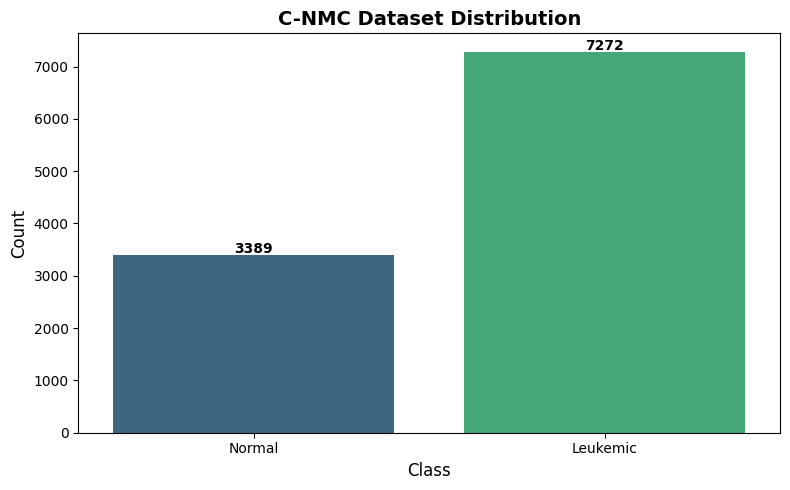

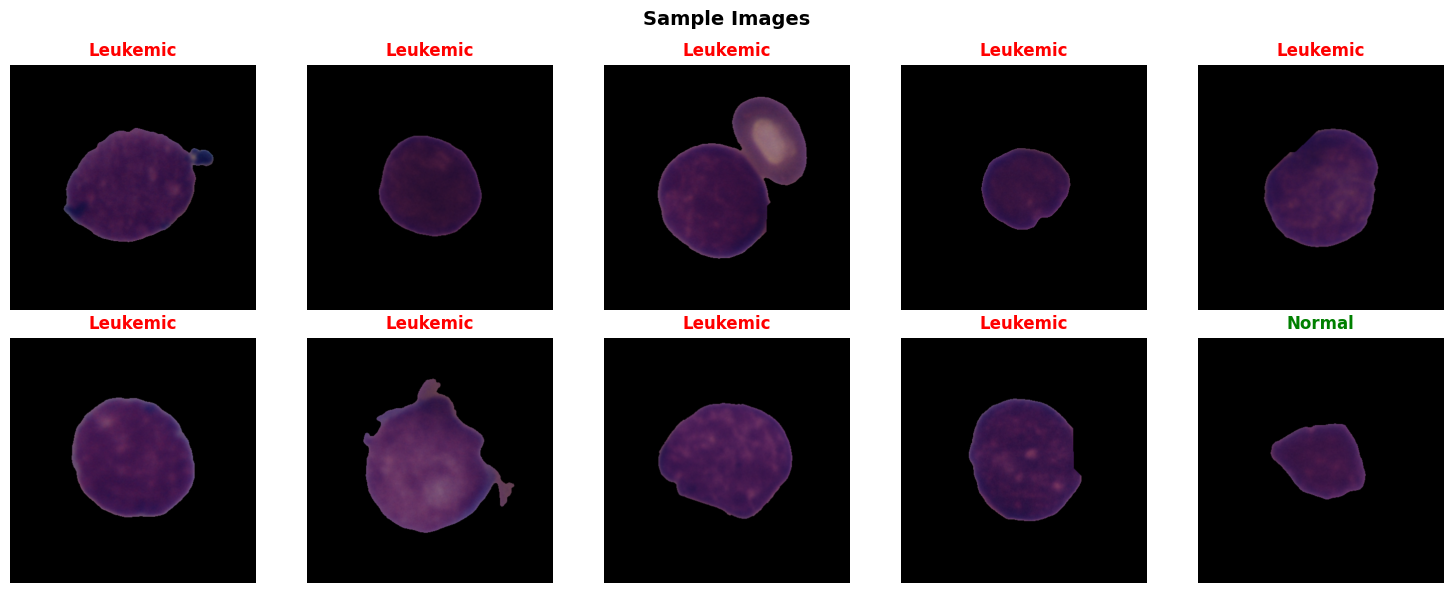

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette='viridis')
plt.title('C-NMC Dataset Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Normal', 'Leukemic'])

for i, v in enumerate(df['label'].value_counts().sort_index()):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    idx = np.random.randint(0, len(df))
    img = cv2.imread(df.iloc[idx]['filepath'])
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        label = 'Normal' if df.iloc[idx]['label'] == 0 else 'Leukemic'
        color = 'green' if df.iloc[idx]['label'] == 0 else 'red'
        axes[i].set_title(label, color=color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ✂️ Step 6: Split Dataset (Train/Val/Test)

In [6]:
print("\n" + "="*70)
print("✂️ SPLITTING DATASET")
print("="*70)

# Separate classes
normal_df = df[df['label'] == 0].reset_index(drop=True)
leukemic_df = df[df['label'] == 1].reset_index(drop=True)

print(f"Normal: {len(normal_df)} | Leukemic: {len(leukemic_df)}")

# Split each class: 80% train, 10% val, 10% test
train_n, temp_n = train_test_split(normal_df, test_size=0.2, random_state=42, stratify=None)
val_n, test_n = train_test_split(temp_n, test_size=0.5, random_state=42, stratify=None)

train_l, temp_l = train_test_split(leukemic_df, test_size=0.2, random_state=42, stratify=None)
val_l, test_l = train_test_split(temp_l, test_size=0.5, random_state=42, stratify=None)

# Combine
train_df = pd.concat([train_n, train_l]).sample(frac=1, random_state=42).reset_index(drop=True)
val_df = pd.concat([val_n, val_l]).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat([test_n, test_l]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTrain: {len(train_df)} | {train_df['label'].value_counts().to_dict()}")
print(f"Val: {len(val_df)} | {val_df['label'].value_counts().to_dict()}")
print(f"Test: {len(test_df)} | {test_df['label'].value_counts().to_dict()}")

# Verify
for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    assert d['label'].nunique() == 2, f"{name} missing class!"

print("\n✅ All splits have both classes!")
print("="*70)


✂️ SPLITTING DATASET
Normal: 3389 | Leukemic: 7272

Train: 8528 | {1: 5817, 0: 2711}
Val: 1066 | {1: 727, 0: 339}
Test: 1067 | {1: 728, 0: 339}

✅ All splits have both classes!


## 🎨 Step 7: Create Data Generators

In [7]:
print("\n" + "="*70)
print("🎨 CREATING DATA GENERATORS")
print("="*70)

IMG_SIZE = 224
BATCH_SIZE = 32

# Convert labels to string
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

# Create generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True, seed=42
)

val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

test_gen = val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print(f"Train batches: {len(train_gen)}")
print(f"Val batches: {len(val_gen)}")
print(f"Test batches: {len(test_gen)}")
print("="*70)


🎨 CREATING DATA GENERATORS
Found 8528 validated image filenames belonging to 2 classes.
Found 1066 validated image filenames belonging to 2 classes.
Found 1067 validated image filenames belonging to 2 classes.
Train batches: 267
Val batches: 34
Test batches: 34


## 🏗️ Step 8: Build VGG16 Model

In [8]:
print("\n" + "="*70)
print("🏗️ BUILDING VGG16")
print("="*70)

base_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_vgg16.trainable = False

model_vgg16 = models.Sequential([
    base_vgg16,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_vgg16.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg16.summary()


🏗️ BUILDING VGG16


I0000 00:00:1775398539.867317      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775398539.873185      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,041 (56.76 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 🏗️ Step 9: Build VGG19 Model

In [9]:
print("\n" + "="*70)
print("🏗️ BUILDING VGG19")
print("="*70)

base_vgg19 = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_vgg19.trainable = False

model_vgg19 = models.Sequential([
    base_vgg19,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_vgg19.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()


🏗️ BUILDING VGG19
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,188,737 (77.01 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

## 🚀 Step 10: Train VGG16 (20 Epochs)

In [10]:
print("\n" + "="*70)
print("🚀 TRAINING VGG16 (20 EPOCHS)")
print("="*70)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('vgg16_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

start = time.time()
history_16 = model_vgg16.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)
time_16 = time.time() - start

print(f"\n✅ VGG16 trained in {time_16/60:.1f} minutes")


🚀 TRAINING VGG16 (20 EPOCHS)
Epoch 1/20


I0000 00:00:1775398545.982652      78 service.cc:152] XLA service 0x7ff5600063a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775398545.982694      78 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775398545.982700      78 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775398546.629702      78 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/267 ━━━━━━━━━━━━━━━━━━━━ 1:10:09 16s/step - accuracy: 0.2500 - loss: 0.9431

I0000 00:00:1775398559.587528      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.6217 - loss: 0.6673
Epoch 1: val_accuracy improved from -inf to 0.68199, saving model to vgg16_best.h5


...

267/267 ━━━━━━━━━━━━━━━━━━━━ 104s 389ms/step - accuracy: 0.7257 - loss: 0.5536 - val_accuracy: 0.7852 - val_loss: 0.4732 - learning_rate: 1.0000e-04
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7588 - loss: 0.5256
Epoch 4: val_accuracy improved from 0.78518 to 0.79644, saving model to vgg16_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 103s 385ms/step - accuracy: 0.7588 - loss: 0.5256 - val_accuracy: 0.7964 - val_loss: 0.4603 - learning_rate: 1.0000e-04
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7613 - loss: 0.5297
Epoch 5: val_accuracy improved from 0.79644 to 0.81426, saving model to vgg16_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 106s 395ms/step - accuracy: 0.7614 - loss: 0.5296 - val_accuracy: 0.8143 - val_loss: 0.4380 - learning_rate: 1.0000e-04
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7857 - loss: 0.4936
Epoch 6: val_accuracy did not improve from 0.81426
267/267 ━━━━━━━━━━━━━━━━━━━━ 105s 394ms/step - accuracy: 0.7857 - loss: 0.4936 - val_accuracy: 0.8086 - val_loss: 0.4454 - learning_rate: 1.0000e-04
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7836 - loss: 0.4901
Epoch 7: val_accuracy did not improve from 0.81426
267/267 ━━━━━━━━━━━━━━━━━━━━ 104s 389ms/step - accuracy: 0.7836 - loss: 0.4902 - val_accuracy: 0.8124 - val_loss: 0.4433 - learning_rate: 1.0000e-04
Epoch 8/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7776 - loss: 0.4971
Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 8: val_accuracy did not improve from 0.81426
267/267 ━━━━━━━━━━━━━━━━━━━━ 103s 385ms/step - accuracy: 0.

267/267 ━━━━━━━━━━━━━━━━━━━━ 102s 381ms/step - accuracy: 0.7805 - loss: 0.4976 - val_accuracy: 0.8180 - val_loss: 0.4336 - learning_rate: 5.0000e-05
Epoch 10/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7870 - loss: 0.4919
Epoch 10: val_accuracy improved from 0.81801 to 0.81895, saving model to vgg16_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 104s 388ms/step - accuracy: 0.7870 - loss: 0.4919 - val_accuracy: 0.8189 - val_loss: 0.4334 - learning_rate: 5.0000e-05
Epoch 11/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7865 - loss: 0.4877
Epoch 11: val_accuracy did not improve from 0.81895
267/267 ━━━━━━━━━━━━━━━━━━━━ 103s 384ms/step - accuracy: 0.7865 - loss: 0.4877 - val_accuracy: 0.8105 - val_loss: 0.4475 - learning_rate: 5.0000e-05
Epoch 12/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.7896 - loss: 0.4862
Epoch 12: val_accuracy did not improve from 0.81895
267/267 ━━━━━━━━━━━━━━━━━━━━ 101s 377ms/step - accuracy: 0.7896 - loss: 0.4862 - val_accuracy: 0.8143 - val_loss: 0.4361 - learning_rate: 5.0000e-05
Epoch 13/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7833 - loss: 0.4851
Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 13: val_accuracy did not improve from 0.81895
267/267 ━━━━━━━━━━━━━━━━━━━━ 103s 384ms/step - accur

## 🚀 Step 11: Train VGG19 (20 Epochs)

In [11]:
print("\n" + "="*70)
print("🚀 TRAINING VGG19 (20 EPOCHS)")
print("="*70)

callbacks_19 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('vgg19_best.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

start = time.time()
history_19 = model_vgg19.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_19,
    verbose=1
)
time_19 = time.time() - start

print(f"\n✅ VGG19 trained in {time_19/60:.1f} minutes")


🚀 TRAINING VGG19 (20 EPOCHS)
Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6350 - loss: 0.6638
Epoch 1: val_accuracy improved from -inf to 0.68199, saving model to vgg19_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 110s 400ms/step - accuracy: 0.6351 - loss: 0.6637 - val_accuracy: 0.6820 - val_loss: 0.5619 - learning_rate: 1.0000e-04
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.6891 - loss: 0.5930
Epoch 2: val_accuracy improved from 0.68199 to 0.75141, saving model to vgg19_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 107s 400ms/step - accuracy: 0.6892 - loss: 0.5929 - val_accuracy: 0.7514 - val_loss: 0.5019 - learning_rate: 1.0000e-04
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.7529 - loss: 0.5412
Epoch 3: val_accuracy improved from 0.75141 to 0.77298, saving model to vgg19_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 107s 402ms/step - accuracy: 0.7529 - loss: 0.5411 - val_accuracy: 0.7730 - val_loss: 0.4775 - learning_rate: 1.0000e-04
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.7573 - loss: 0.5251
Epoch 4: val_accuracy improved from 0.77298 to 0.80582, saving model to vgg19_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 111s 414ms/step - accuracy: 0.7573 - loss: 0.5251 - val_accuracy: 0.8058 - val_loss: 0.4453 - learning_rate: 1.0000e-04
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.7621 - loss: 0.5192
Epoch 5: val_accuracy did not improve from 0.80582
267/267 ━━━━━━━━━━━━━━━━━━━━ 109s 408ms/step - accuracy: 0.7621 - loss: 0.5192 - val_accuracy: 0.7805 - val_loss: 0.4655 - learning_rate: 1.0000e-04
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.7714 - loss: 0.5005
Epoch 6: val_accuracy improved from 0.80582 to 0.81426, saving model to vgg19_best.h5


267/267 ━━━━━━━━━━━━━━━━━━━━ 111s 414ms/step - accuracy: 0.7714 - loss: 0.5005 - val_accuracy: 0.8143 - val_loss: 0.4368 - learning_rate: 1.0000e-04
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7738 - loss: 0.5044
Epoch 7: val_accuracy did not improve from 0.81426
267/267 ━━━━━━━━━━━━━━━━━━━━ 148s 553ms/step - accuracy: 0.7738 - loss: 0.5044 - val_accuracy: 0.8021 - val_loss: 0.4480 - learning_rate: 1.0000e-04
Epoch 8/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.7836 - loss: 0.4894
Epoch 8: val_accuracy did not improve from 0.81426
267/267 ━━━━━━━━━━━━━━━━━━━━ 111s 414ms/step - accuracy: 0.7836 - loss: 0.4894 - val_accuracy: 0.8002 - val_loss: 0.4463 - learning_rate: 1.0000e-04
Epoch 9/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.7835 - loss: 0.4910
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 9: val_accuracy did not improve from 0.81426
267/267 ━━━━━━━━━━━━━━━━━━━━ 109s 406ms/step - accuracy: 0.

## 📊 Step 12: Plot Training History

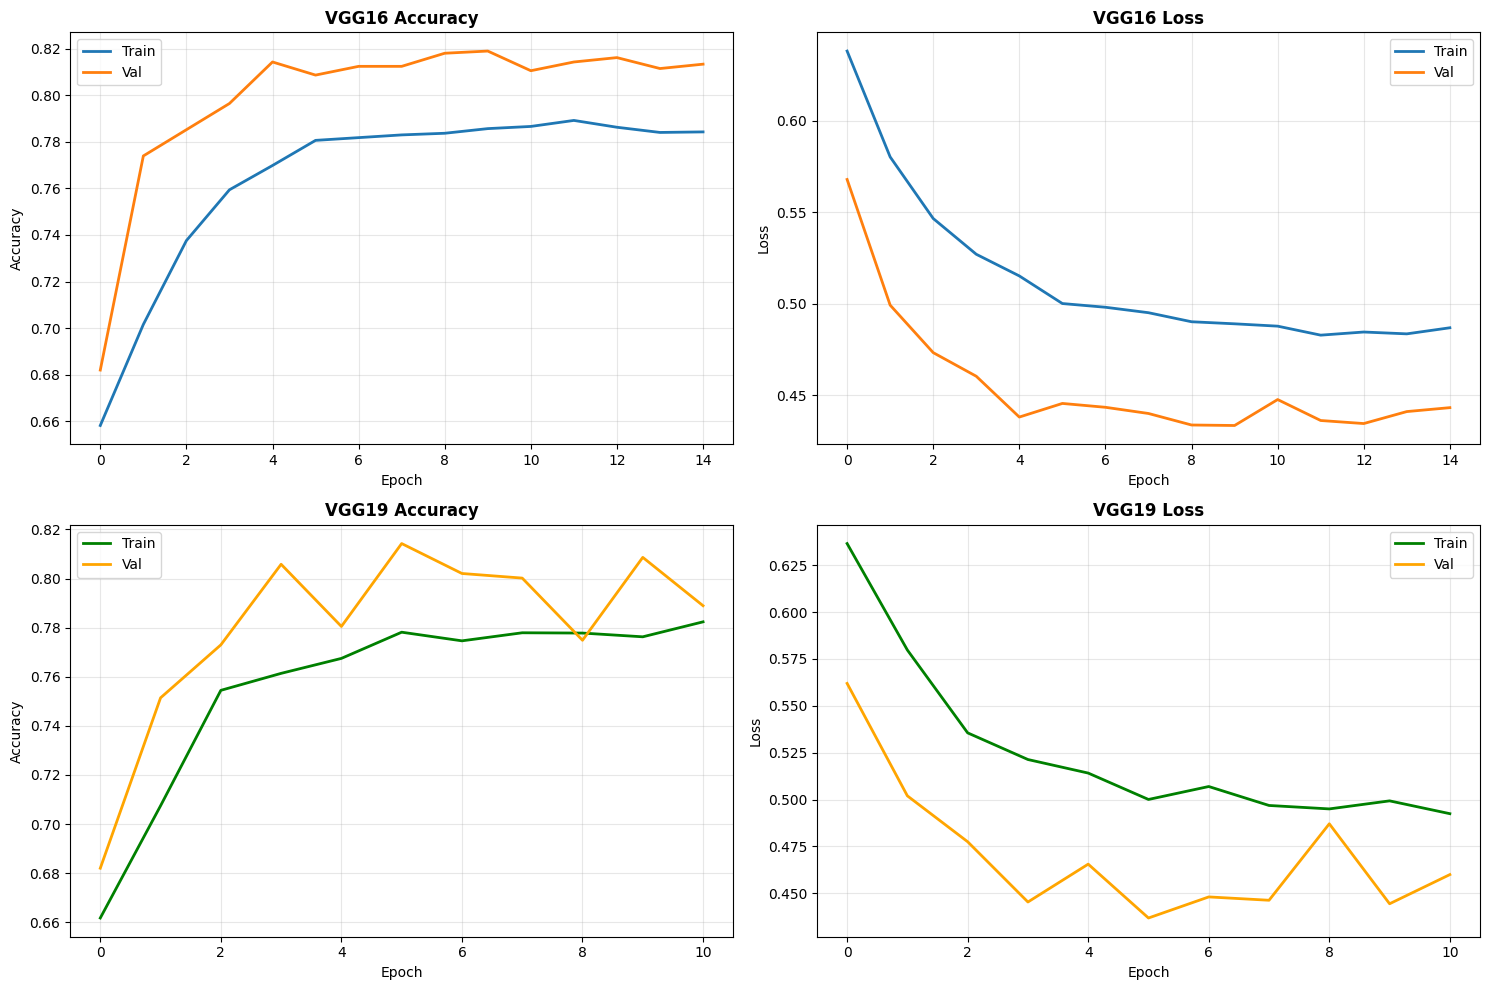

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# VGG16 Accuracy
axes[0,0].plot(history_16.history['accuracy'], label='Train', linewidth=2)
axes[0,0].plot(history_16.history['val_accuracy'], label='Val', linewidth=2)
axes[0,0].set_title('VGG16 Accuracy', fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# VGG16 Loss
axes[0,1].plot(history_16.history['loss'], label='Train', linewidth=2)
axes[0,1].plot(history_16.history['val_loss'], label='Val', linewidth=2)
axes[0,1].set_title('VGG16 Loss', fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# VGG19 Accuracy
axes[1,0].plot(history_19.history['accuracy'], label='Train', linewidth=2, color='green')
axes[1,0].plot(history_19.history['val_accuracy'], label='Val', linewidth=2, color='orange')
axes[1,0].set_title('VGG19 Accuracy', fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# VGG19 Loss
axes[1,1].plot(history_19.history['loss'], label='Train', linewidth=2, color='green')
axes[1,1].plot(history_19.history['val_loss'], label='Val', linewidth=2, color='orange')
axes[1,1].set_title('VGG19 Loss', fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🧪 Step 13: Evaluate Models

In [13]:
print("\n" + "="*70)
print("🧪 EVALUATING MODELS")
print("="*70)

# Load best models
model_vgg16.load_weights('vgg16_best.h5')
model_vgg19.load_weights('vgg19_best.h5')

# Evaluate
print("\n📊 VGG16 Results:")
train_acc_16 = max(history_16.history['accuracy'])
val_acc_16 = max(history_16.history['val_accuracy'])
test_loss_16, test_acc_16 = model_vgg16.evaluate(test_gen, verbose=0)

print(f"Train Acc: {train_acc_16:.4f} ({train_acc_16*100:.2f}%)")
print(f"Val Acc:   {val_acc_16:.4f} ({val_acc_16*100:.2f}%)")
print(f"Test Acc:  {test_acc_16:.4f} ({test_acc_16*100:.2f}%)")

print("\n📊 VGG19 Results:")
train_acc_19 = max(history_19.history['accuracy'])
val_acc_19 = max(history_19.history['val_accuracy'])
test_loss_19, test_acc_19 = model_vgg19.evaluate(test_gen, verbose=0)

print(f"Train Acc: {train_acc_19:.4f} ({train_acc_19*100:.2f}%)")
print(f"Val Acc:   {val_acc_19:.4f} ({val_acc_19*100:.2f}%)")
print(f"Test Acc:  {test_acc_19:.4f} ({test_acc_19*100:.2f}%)")

print("="*70)


🧪 EVALUATING MODELS

📊 VGG16 Results:
Train Acc: 0.7892 (78.92%)
Val Acc:   0.8189 (81.89%)
Test Acc:  0.7863 (78.63%)

📊 VGG19 Results:
Train Acc: 0.7824 (78.24%)
Val Acc:   0.8143 (81.43%)
Test Acc:  0.7779 (77.79%)


## 📈 Step 14: Final Results & Comparison


📈 FINAL RESULTS SUMMARY


Model Train Acc Val Acc Test Acc Train Time (min)
VGG16    0.7892  0.8189   0.7863            27.13
VGG19    0.7824  0.8143   0.7779            20.66

🏆 BEST MODEL: VGG16
🏆 BEST TEST ACCURACY: 0.7863 (78.63%)


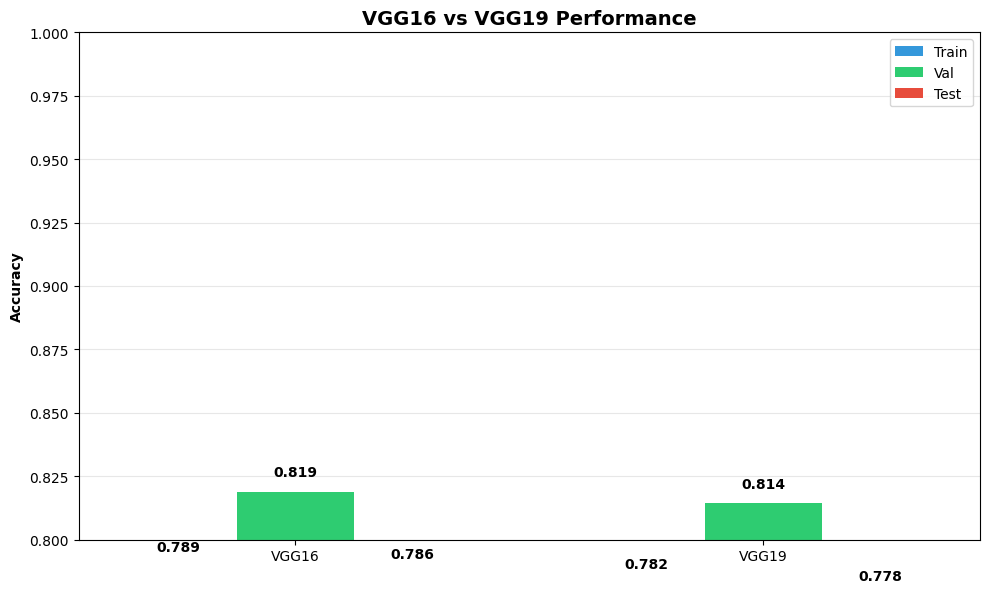

In [14]:
print("\n" + "="*70)
print("📈 FINAL RESULTS SUMMARY")
print("="*70)

# Test predictions for detailed metrics
test_gen.reset()
y_pred_16 = (model_vgg16.predict(test_gen, verbose=0) > 0.5).astype(int).flatten()
y_true = test_gen.classes

test_gen.reset()
y_pred_19 = (model_vgg19.predict(test_gen, verbose=0) > 0.5).astype(int).flatten()

# Create results dataframe
results = pd.DataFrame({
    'Model': ['VGG16', 'VGG19'],
    'Train Acc': [f'{train_acc_16:.4f}', f'{train_acc_19:.4f}'],
    'Val Acc': [f'{val_acc_16:.4f}', f'{val_acc_19:.4f}'],
    'Test Acc': [f'{test_acc_16:.4f}', f'{test_acc_19:.4f}'],
    'Train Time (min)': [f'{time_16/60:.2f}', f'{time_19/60:.2f}']
})

print("\n")
print(results.to_string(index=False))

# Save results
results.to_csv('results.csv', index=False)

# Determine best model
if test_acc_16 > test_acc_19:
    best = 'VGG16'
    best_acc = test_acc_16
else:
    best = 'VGG19'
    best_acc = test_acc_19

print(f"\n🏆 BEST MODEL: {best}")
print(f"🏆 BEST TEST ACCURACY: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("="*70)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.25

bars1 = ax.bar(x - width, [train_acc_16, train_acc_19], width, label='Train', color='#3498db')
bars2 = ax.bar(x, [val_acc_16, val_acc_19], width, label='Val', color='#2ecc71')
bars3 = ax.bar(x + width, [test_acc_16, test_acc_19], width, label='Test', color='#e74c3c')

ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('VGG16 vs VGG19 Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['VGG16', 'VGG19'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.8, 1.0)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 Step 15: Confusion Matrices

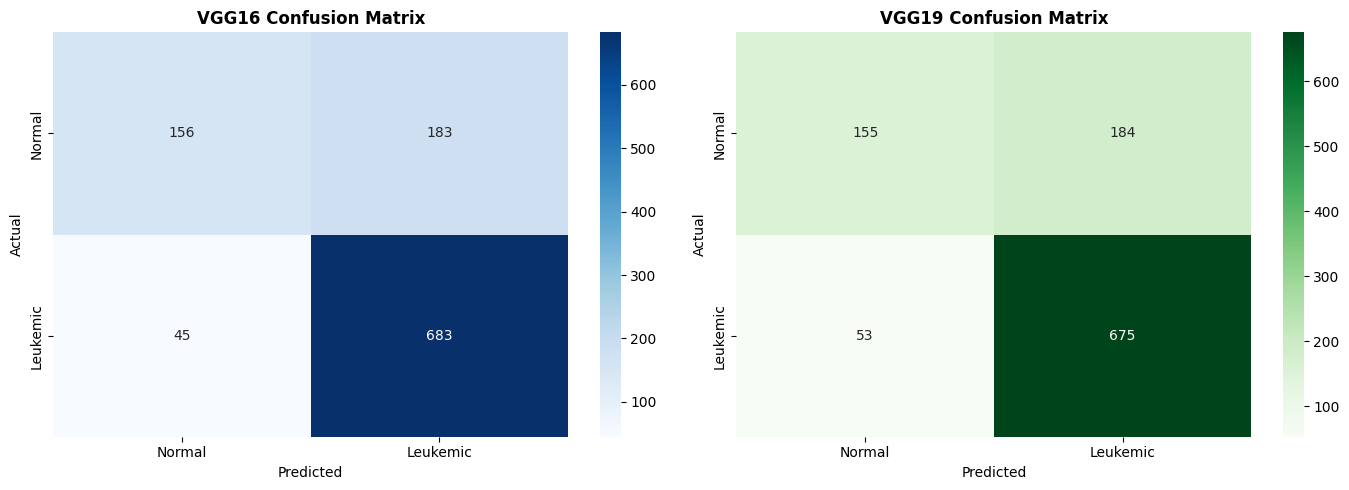


📋 VGG16 Classification Report:
              precision    recall  f1-score   support

      Normal       0.78      0.46      0.58       339
    Leukemic       0.79      0.94      0.86       728

    accuracy                           0.79      1067
   macro avg       0.78      0.70      0.72      1067
weighted avg       0.78      0.79      0.77      1067


📋 VGG19 Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      0.46      0.57       339
    Leukemic       0.79      0.93      0.85       728

    accuracy                           0.78      1067
   macro avg       0.77      0.69      0.71      1067
weighted avg       0.77      0.78      0.76      1067



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VGG16
cm16 = confusion_matrix(y_true, y_pred_16)
sns.heatmap(cm16, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Leukemic'],
            yticklabels=['Normal', 'Leukemic'])
axes[0].set_title('VGG16 Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# VGG19
cm19 = confusion_matrix(y_true, y_pred_19)
sns.heatmap(cm19, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Leukemic'],
            yticklabels=['Normal', 'Leukemic'])
axes[1].set_title('VGG19 Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Print classification reports
print("\n📋 VGG16 Classification Report:")
print(classification_report(y_true, y_pred_16, target_names=['Normal', 'Leukemic']))

print("\n📋 VGG19 Classification Report:")
print(classification_report(y_true, y_pred_19, target_names=['Normal', 'Leukemic']))

## 💾 Step 16: Save Models & Final Summary

In [16]:
print("\n" + "="*70)
print("💾 SAVING MODELS")
print("="*70)

model_vgg16.save('vgg16_final.h5')
model_vgg19.save('vgg19_final.h5')

print("✅ Models saved:")
print("  - vgg16_best.h5 (best weights)")
print("  - vgg19_best.h5 (best weights)")
print("  - vgg16_final.h5")
print("  - vgg19_final.h5")
print("  - results.csv")

print("\n" + "="*70)
print("🎉 TRAINING COMPLETE!")
print("="*70)
print(f"\n📊 Summary:")
print(f"  • Dataset: {len(df)} images ({normal_count} Normal, {leukemic_count} Leukemic)")
print(f"  • Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}")
print(f"  • VGG16 Test Acc: {test_acc_16*100:.2f}%")
print(f"  • VGG19 Test Acc: {test_acc_19*100:.2f}%")
print(f"  • Best Model: {best} ({best_acc*100:.2f}%)")
print(f"  • Total Train Time: {(time_16 + time_19)/60:.1f} minutes")
print("="*70)


💾 SAVING MODELS
✅ Models saved:
  - vgg16_best.h5 (best weights)
  - vgg19_best.h5 (best weights)
  - vgg16_final.h5
  - vgg19_final.h5
  - results.csv

🎉 TRAINING COMPLETE!

📊 Summary:
  • Dataset: 10661 images (3389 Normal, 3883 Leukemic)
  • Train/Val/Test: 8528/1066/1067
  • VGG16 Test Acc: 78.63%
  • VGG19 Test Acc: 77.79%
  • Best Model: VGG16 (78.63%)
  • Total Train Time: 47.8 minutes
